# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [1]:
import os
import sys
from pathlib import Path
import time
import json
import numpy as np
import diffusers
import xarray as xr
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
from pprint import pprint

from abc import ABC, abstractmethod
from collections import defaultdict
import copy
import dataclasses


# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals
import diffusionsim.models as models
import diffusionsim as diff

# Debugging Training Classes

In [3]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True
dataset_type="climsim"

## Diffusion Training

In [6]:

trainer = None
num_epochs = 2
REF_BATCH_SIZE = 64
dataset_type = "climsim_diffusion1d"
image_dim = 1
data_vars = 'v1'
in_notebook = True
NUM_MODELS = 3

RESTART_FROM_CKPT = False
RERUN = False
torch.set_grad_enabled(True)

EXP_DIR = "/mnt/home/ssa2206/Climsim/experiments"

exp_id = "diffusion_hp_search"
run_id = "modulus_v1"

In [7]:
tconfigs, mconfigs, dconfig = setup_diffusion_run(
    NUM_MODELS, exp_id, run_id, data_vars, image_dim, batch_size=32, shuffle_indices=False, use_tendencies=False
)

In [8]:

run_start_time = tru.log_event("run start", exp_id=exp_id, run_id=run_id)
t0 =  tru.log_event("setup start", run_id=run_id)
base_dir = os.path.join(EXP_DIR, exp_id)
tconfigs, mconfigs, dconfig = setup_diffusion_run(
    NUM_MODELS, exp_id, run_id, data_vars, image_dim, batch_size=32, shuffle_indices=False, use_tendencies=False
)
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)
scheduler = models.SchedulerParams(
    model_type = "ddpm-scheduler",
    beta_schedule = "linear",
    clip_sample = False,
    clip_sample_range = 4.0,
    beta_end = 0.02,
    prediction_type = "v_prediction"
)
scheduler = models.load_model(scheduler, apply_lens=False)

{"event": "run start", "time": 1757830958.1436188, "pid": 3386099, "exp_id": "diffusion_hp_search", "run_id": "modulus_v1"}
{"event": "setup start", "time": 1757830958.1452303, "pid": 3386099, "run_id": "modulus_v1"}
ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [17]:
images = next(iter(dataloaders[0])).to(device)

{"event": "get-item start", "time": 1757831039.421268, "pid": 3386099, "batch_idx": 0}
{"event": "get-item end", "time": 1757831041.1199014, "pid": 3386099, "batch_idx": 0, "duration": 1.6986312866210938}


In [19]:
noises = torch.randn(images.shape, device=device)
tconfig = tconfigs[-1]
timesteps = torch.randint(0, tconfig.max_T_sample, size=(images.shape[0],), device=device, dtype=torch.int64)
xt = scheduler.add_noise(images, noises, timesteps)
if scheduler.config.prediction_type == 'v_prediction':
    target = scheduler.get_velocity(images, noises, timesteps)
else:
    target = noises

In [63]:
trainer = DiffusionTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id, scheduler)

In [68]:
trainer.optimizers['modulus_v1a'].state.values()

dict_values([])

In [53]:
model = trainer.models['modulus_v1c']
model.device

device(type='cuda', index=0)

In [56]:
move_optimizer(trainer.optimizers['modulus_v1c'], "cpu")

In [69]:
RESTART_FROM_CKPT = False
if (RESTART_FROM_CKPT):
    trainer.restart_from_ckpt(num_epochs, log=True, cid='')
else:
    trainer.train(num_epochs, log=True)
print("Done!", flush=True)

Getting ready to train 3 model(s) for 2 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/modulus_v1.json


epoch,▁
train/modulus_v1a/loss,▁
train/modulus_v1b/loss,▁
train/modulus_v1c/loss,▁
epoch,0
train/modulus_v1a/loss,1.44921
train/modulus_v1b/loss,1.46312
train/modulus_v1c/loss,1.44355


Saving configs to /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/modulus_v1.json
Epoch 0/1
__________


{"event": "train epoch-0 start", "time": 1757832135.6802337, "pid": 3386099}
{"event": "get-item start", "time": 1757832135.6826348, "pid": 3386099, "batch_idx": 0}



Currently at train epoch 0, step 0/1
________________________________________________


...


Currently at train epoch 1, step 0/1
________________________________________________


{"event": "get-item end", "time": 1757832142.4733832, "pid": 3386099, "batch_idx": 0, "duration": 1.5479943752288818}
{"event": "run-batch start", "time": 1757832142.4797924, "pid": 3386099}
/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


modulus_v1a
Allocated: 992.57 MB
Reserved:  2460.00 MB
Allocated: 992.58 MB
Reserved:  2298.00 MB
modulus_v1b
Allocated: 992.58 MB
Reserved:  2298.00 MB
Allocated: 992.58 MB
Reserved:  2300.00 MB
modulus_v1c
Allocated: 992.58 MB
Reserved:  2300.00 MB
Allocated: 992.58 MB
Reserved:  2298.00 MB

Finished train epoch 1
avg loss for epoch 1, run_id='modulus_v1a': 1.4621622562408447
avg loss for epoch 1, run_id='modulus_v1b': 1.4556277990341187
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/modulus_v/best-modulus_v1b-ckpt.pt
new best! saving new checkpoint at epoch 1
avg loss for epoch 1, run_id='modulus_v1c': 1.4473735094070435


{"event": "run-batch end", "time": 1757832145.597216, "pid": 3386099, "duration": 3.1174216270446777, "modulus_v1a": 1.4621622562408447, "modulus_v1b": 1.4556277990341187, "modulus_v1c": 1.4473735094070435}
{"event": "train epoch-1 end", "time": 1757832145.5978613, "pid": 3386099, "duration": 4.674780607223511}


Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/modulus_v/best-modulus_v1c-ckpt.pt
new best! saving new checkpoint at epoch 1
Finished training 3 model(s) for 2 epochs.
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/modulus_v/modulus_v1a-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/modulus_v/modulus_v1b-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/modulus_v/modulus_v1c-ckpt.pt
Done!


### Overfit one sample

In [ ]:
loss = 10
#trainer = self = DiffusionTrainerTest(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=15, gamma=0.9)
self.lr_schedulers['modulus_v1c'] = lr_scheduler
losses, lrs = [], []
step = 0
while loss > 0.40 and step < 1000:
    loss = self._run_batch(x0, step, timesteps, eps)['modulus_v1c']
    losses.append(loss)
    step += 1 
print("done at step", step, "loss", loss)

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


done at step 59 loss 0.39139899611473083


In [ ]:
loss = 10
loss_fn = torch.nn.MSELoss()
#trainer = self = DiffusionTrainerTest(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=15, gamma=0.9)
self.lr_schedulers['modulus_v1c'] = lr_scheduler
losses, lrs = [], []
step = 0
while loss > 0.40 and step < 1000:
    pred = model(xt, timesteps).sample
    loss = loss_fn(pred, target)
    optim.zero_grad()
    loss.backward()
    optim.step()
    losses.append(loss.item())
    lr_scheduler.step()
    lrs.append(lr_scheduler.get_last_lr()[0])
    step += 1 
print("done at step", step, "loss", loss)

done at step 59 loss tensor(0.3860, device='cuda:0', grad_fn=<MseLossBackward0>)


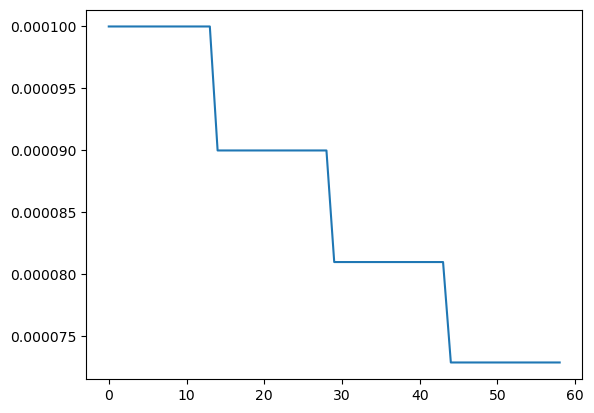

In [ ]:
plt.plot(lrs)

In [ ]:
losses = defaultdict(list)

for step in range(100):
    for run_id in self._run_batch(images[:64], step):
        losses[run_id].append(batch_losses[run_id])
    

In [ ]:
self.optimizers['modulus_v1a'].param_groups[1]['params'][0] is self.models['modulus_v1a'].get_param(-1)

True

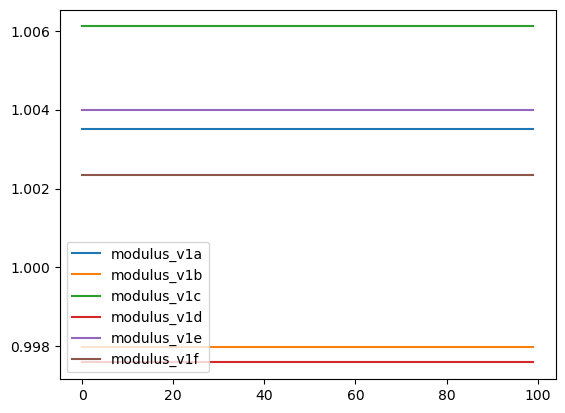

In [ ]:
for key in losses:
    plt.plot(losses[key], label=key)
plt.legend()
plt.show()


### Cleaning legacy dataclass formats

In [ ]:
pkeys = "num_epochs phases distributed_training batch_logging_interval batch_checkpoint_interval log_gradients".split()
delete = True
import inspect
for key in pkeys:
    for run_id in run.run_ids:
        tconfig = run.logs[run_id]['training_config']
        if key in tconfig:
            print(key, tconfig[key])
            if delete and key in inspect.signature(tru.DataConfig).parameters:
                run.logs['data_config'][key] = copy.deepcopy(tconfig[key])
                del tconfig[key]
        else:
            print(key, "not found")
            break

NameError: name 'run' is not defined

In [ ]:
rids = run.run_ids
for r in rids:
    tcon = run.logs[r]['training_config']
    run.logs['data_config']['checkpoint_best_epoch'] = tcon['save_best_epoch']
    del tcon['save_best_epoch']

NameError: name 'run' is not defined

## Train Clim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128, use_tendencies=True, shuffle_indices=False):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices,
                                dataset_type, batch_size, use_tendencies,
                             )
    dconfig.train_test_split = [0.001, 0.001]
    dconfig.checkpoint_every_epoch = True
    dconfig.phases = ['train', 'eval']
    dconfig.log_gradients = True
    tconfigs, mconfigs = [], []

    learning_rates = [1e-3] * num_models
    distloss_weights = [0.0] * num_models
    diffloss_weights = [0.0, 10.0, 10.0]
    diff_start_epochs = [0,0,0] # [11, 1, 1]

    image_dim = 1
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]
    run_ids = ["mse-only", "decode-only", "encode-decode"]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=run_ids[i])
        tconfig.learning_rate_params.update(dict(
            learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE,
            lr_scheduler="steplr",
            step_size=1,
            gamma=0.85,
            min_lr=1e-6,
        ))

        loss_weights = {'mse': 1.0, 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': [0,100], 'distribution': [0,100], 'diffusion': [diff_start_epochs[i],100]}
        tconfig.loss_weight_params.update(dict(
            loss_weights=loss_weights,
            loss_schedule=loss_schedule,
            alpha=0.5, 
            strategy="gradnorm",
            update_interval=20,
        ))

        tconfig.clip_gradients = True
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians[:len(target_variables_distloss)]
        
        tconfig.diffusion_loss_noise_level = 10
        tconfig.diffusion_strategy = "1d-decode-only" if i<2 else "1d-encode-decode"
        #tconfig.diffusion_image_loss = "1d-mse"
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(scheduler=tru.SchedulerParams(
            prediction_type="epsilon",
            beta_schedule="linear",
        ))
        mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



In [ ]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = "decode-only-test"
num_models = 3
base_dir = os.path.join(exp_dir, exp_id)

In [ ]:
run = evals.Run(exp_id, "decode-only", climsim_run = True)

In [ ]:
run.logs['decode-only']['losses'].keys()

dict_keys(['train', 'eval'])

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64, use_tendencies=True
)

In [ ]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train', 'eval'],
           train_test_split=[0.001, 0.001],
           dataloader_params=DataLoaderParams(batch_size=64,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           shuffle_indices=False,
           distributed_training=False,
           checkpoint_best_epoch=True,
    

In [ ]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)
ds = dataloaders[0].dataset
dutils = ds.dutils

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [ ]:
unet = tru.load_diffusion_model(model_id='diff_1d_v1')
scheduler = tru.load_scheduler(mconfigs[0])

In [ ]:
unet.config.down_block_types

['DownResnetBlock1D', 'AttnDownBlock1D', 'DownBlock1D']

In [ ]:

AbstractTrainer = trainers.AbstractTrainer
diffusion_loss = trainers.diffusion_loss
distribution_loss = trainers.distribution_loss
register_incident = trainers.register_incident


In [ ]:

class ClimsimTrainer(AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, **kwargs):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id)
        self.tracked_losses = ["mse"]
        self.track_loss_weights = False
        for run_id in self.run_ids:
            lw_params = self.training_configs[run_id].loss_weight_params #@['weights']
            
            for ltype in ["distribution", "diffusion"]:
                if(lw_params['loss_weights'][ltype] > 0 and ltype not in self.tracked_losses):
                    self.tracked_losses.append(ltype)
            
            if(lw_params['strategy'] == "gradnorm"):
                self.track_loss_weights = True
                self.gradnorm_loss_fn = torch.nn.L1Loss(reduction='sum')

        if ("diffusion" in self.tracked_losses):
            assert 'unet' in kwargs, "unet must be provided for diffusion loss"
            self.unet = kwargs['unet'].to(self.device)
            scheds = [kwargs['scheduler'] for _ in range(len(self.run_ids))] if 'scheduler' in kwargs else [tru.load_scheduler(mconfig) for mconfig in self.mconfigs.values()]
            self.schedulers = dict(zip(self.run_ids, scheds))
        #if ("distribution" in self.tracked_losses):
        
    def _make_image(self, y, image_dim=1):
        if not torch.is_tensor(y):
            y = torch.tensor(y)
        ds = self.dataloaders['train'].dataset
        # desired output is (BS, C, H, W)
        return(tru.imagify(y, ds.dutils, 'y', image_dim))

    def setup_training(self, num_epochs, log=True, save_indices=False):
        super().setup_training(num_epochs, log, save_indices)
        self.loss_weights, self.lw_optimizers, self.lw_history, self.L0 = {}, {}, defaultdict(list), defaultdict(dict)
        for run_id in self.run_ids:
            params = self.training_configs[run_id].loss_weight_params
            lws = [params['loss_weights'][k] for k in self.tracked_losses]
            if self.track_loss_weights:
                lws = torch.tensor(lws, device=self.device, dtype=torch.float32).mul_(params['T'] / sum(lws))
                self.loss_weights[run_id] = lws.requires_grad_(True)
                self.lw_optimizers[run_id] = torch.optim.SGD([self.loss_weights[run_id]], lr=self.training_configs[run_id].loss_weight_params['lr'])
                self.lw_history[run_id].append(lws.detach().cpu().numpy().tolist())
            else: 
                self.loss_weights[run_id] = torch.tensor(lws, device=self.device, requires_grad=False, dtype=torch.float32) / sum(lws)
    
    def _return_loss_weights(self, run_id, batch_losses=None):
        lw_params = self.training_configs[run_id].loss_weight_params
        loss_weight = self.loss_weights[run_id].detach().clone()
        for i, loss_type in enumerate(self.tracked_losses):
            loss_sched = lw_params['loss_schedule'][loss_type]
            if (isinstance(loss_sched, int) and self.current_epoch < loss_sched):
                loss_weight[i] = 0
            elif isinstance(loss_sched, list) and not (loss_sched[0] <= self.current_epoch < loss_sched[1]):
                loss_weight[i] = 0
        return(loss_weight)
            
    def apply_loss(self, y_hat, batch, batch_losses, run_id, step):
        #model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
        x, y = batch[0].to(self.device), batch[1].to(self.device)
        self.models[run_id].zero_grad()
        VAR_IND = None
        for loss_type in self.tracked_losses:
            if(loss_type == "mse"):
                loss = self.loss_fn(y_hat, y)
            elif(loss_type == "distribution"):
                loss, VAR_IND = distribution_loss(self, y_hat, y, run_id, step)
                batch_losses[run_id]['VAR_IND'] = VAR_IND
            elif(loss_type == "diffusion"):
                loss = diffusion_loss(self, y_hat, run_id)
            else:
                raise ValueError(f"Invalid loss type: {loss_type}")
            if(self.current_phase == 'train' and self._gradients_ops(run_id, loss_type, loss, step)):
                self.nan_incidents[run_id][-1]['inputs'] = batch
                loss = torch.tensor(0)
            batch_losses[run_id][loss_type] = loss
        losses = torch.stack([batch_losses[run_id][l] for l in self.tracked_losses]).float()
        if(self.track_loss_weights and 'l0' not in self.L0[run_id]):
            self.L0[run_id]['l0'] = torch.clamp(losses.detach().clone(), max=200)
        if (self.track_loss_weights and VAR_IND is not None):
            if (self.L0[run_id].get(VAR_IND, 200) >= 150 and batch_losses[run_id]['distribution'] < 150):
                self.L0[run_id][VAR_IND] = batch_losses[run_id]['distribution'].detach().clone()
        return(losses)

    def _update_gradnorm_weights(self, run_id, batch_losses):
        params = self.training_configs[run_id].loss_weight_params
        W = self.loss_weights[run_id]
        assert W.requires_grad, "loss weights must require grad"
        param, grads = self.models[run_id].get_param(params['gradnorm_layer']), []
        for i, loss_type in enumerate(self.tracked_losses):
            grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
            grads.append(torch.norm(grad))
        grads = torch.stack(grads)
        losses = torch.stack([batch_losses[l] for l in self.tracked_losses]).detach()
        l0 = self.L0[run_id]['l0']
        if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
            i = self.tracked_losses.index("distribution")
            l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
        loss_ratio = losses / l0
        target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
        gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
        w_grad = torch.autograd.grad(gradnorm_loss, W, retain_graph=False)[0]
        with torch.no_grad():
            W = W - params['lr'] * w_grad
            if (W < 0).any():
                W = torch.clamp(torch.exp(W), min=1e-3)
            self.loss_weights[run_id] = (params['T'] * W/W.sum()).detach().requires_grad_(True)

    def _run_batch(self, batch, step):
        print(f"Running batch {step}")
        x, y = batch[0].to(self.device), batch[1].to(self.device)
        batch_losses = {}
        for run_id in self.run_ids:
            lw_params = self.training_configs[run_id].loss_weight_params
            batch_losses[run_id] = {}
            y_hat = self.models[run_id](x) 
            losses = self.apply_loss(y_hat, batch, batch_losses, run_id, step)
            if self.current_phase == 'train':
                loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
                if(lw_params['strategy'] == "gradnorm" and step % lw_params['update_interval'] == 0):
                    if (loss_weights > 0).sum().item() > 1:
                        self.lw_history[run_id].append(loss_weights.detach().cpu().numpy().tolist())
                        self._update_gradnorm_weights(run_id, batch_losses[run_id])
                total_loss = loss_weights @ losses
                self.optimizers[run_id].zero_grad()
                total_loss.backward(retain_graph=True)
                if(self.training_configs[run_id].clip_gradients):
                    torch.nn.utils.clip_grad_norm_(self.models[run_id].parameters(), max_norm=1.0)
                self.optimizers[run_id].step()
                if(self.lr_schedulers[run_id] is not None):
                    self.lr_schedulers[run_id].step()
                batch_losses[run_id]['total'] = total_loss.item()
        return(batch_losses)
    
    def _gradients_ops(self, run_id, loss_type, loss, step):
        #assert loss_type in self.tracked_losses, f"loss_type {loss_type} must be one of {self.tracked_losses}"
        model, optimizer = self.models[run_id], self.optimizers[run_id]
        
        if not torch.isfinite(loss):
            return register_incident(self, "LOSS is not finite (NaN or Inf)", step, run_id, loss_type, loss=loss.detach())

        if (self.dconfig.log_gradients and step % self.bli == 0):
            optimizer.zero_grad(set_to_none=True)           # clean slate
            loss.backward(retain_graph=True)
            gdict = self.gradients.setdefault(run_id, {}).setdefault(loss_type, {})
            payload = model.log_gradients(gdict)
            if payload:
                return register_incident(self, "GRAD has NaN/Inf", step, run_id, loss_type, loss=loss.detach(), **payload)
        optimizer.zero_grad(set_to_none=True)
        return 0

    def log_step(self, batch_losses, step):
        if(self.log):
            wandb_metrics = {"epoch" : self.current_epoch}
            for run_id in self.run_ids:
                if('distribution' in self.tracked_losses):
                    wandb_metrics[f"{self.current_phase}/{run_id}/distloss_var"] = batch_losses[run_id]['VAR_IND']
                for loss_type in self.tracked_losses:
                    wandb_metrics[f"{self.current_phase}/{run_id}/{loss_type}"] = batch_losses[run_id][loss_type]
            #global_step = self.current_epoch * len(self.dataloaders[phase]) + step
            self.run.log(wandb_metrics)
        
        if (step % self.bli == 0 or step + 1 == len(self.dataloaders[self.current_phase])):
            for run_id in self.run_ids:
                ldict = self.losses.setdefault(run_id, {}).setdefault(self.current_phase, {})
                for loss_type in self.tracked_losses:
                    ldict.setdefault(loss_type, []).append(batch_losses[run_id][loss_type].item())
                    if loss_type == 'distribution':
                        ldict.setdefault('distloss_var', []).append(batch_losses[run_id]['VAR_IND'])
        
        if ( (step + 1) % self.ckpt_interval == 0 and self.current_phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
        
    def _log_epoch_info(self):
        for run_id in self.run_ids:
            total_loss = 0.0
            tconfig = self.training_configs[run_id]
            for loss_type in self.tracked_losses:
                ind = self.batches_per_epoch[self.current_phase] // self.bli + 1
                epoch_loss = self.losses[run_id][self.current_phase][loss_type][-ind:]
                avg_loss = sum(epoch_loss) / len(epoch_loss)
                print(f"avg {loss_type} loss for {self.current_phase} epoch {self.current_epoch}, {run_id=}: {avg_loss}", flush=True)
                total_loss += tconfig.loss_weight_params['loss_weights'][loss_type] * avg_loss
            
            if(self.current_phase == 'train'): 
                if total_loss < self.best_losses.setdefault(run_id, float('inf')):
                    self._save_checkpoint(run_id, cid='best-')
                    print(f"new best! saving new checkpoint at epoch {self.current_epoch}", flush=True)
                    self.best_losses[run_id] = total_loss
                elif tconfig.checkpoint_every_epoch: # no need to save twice
                    self._save_checkpoint(run_id, f"epoch-{self.current_epoch}")
        print(f"LO before update log file {self.L0}")
        if self.log:
            self.update_log_file()
        print(f"LO after update log file {self.L0}")
    


In [ ]:
trainer = self = ClimsimTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id, unet=unet, scheduler=scheduler)
for r, tcon in self.training_configs.items():
    tcon.loss_weight_params['update_interval'] = 1
tcon.loss_weight_params

{'strategy': 'gradnorm',
 'lr': 1.0,
 'alpha': 0.5,
 'gradnorm_layer': -2,
 'T': 3.0,
 'update_interval': 1,
 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0},
 'loss_schedule': {'mse': [0, 100],
  'distribution': [0, 100],
  'diffusion': [0, 100]}}

In [ ]:
trainer.train(2, log=True, setup=True, run_eval_epoch=True)

Getting ready to train 3 model(s) for 2 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json


epoch,▁▁▁███
train/decode-only/diffusion,█▅▄▂▂▁
train/decode-only/mse,█▅▄▂▂▁
train/encode-decode/diffusion,█▅▄▂▂▁
train/encode-decode/mse,█▅▄▂▂▁
train/mse-only/diffusion,█▆▄▃▂▁
train/mse-only/mse,█▆▄▃▂▁
epoch,1
train/decode-only/diffusion,0.00552
train/decode-only/mse,0.04042
train/encode-decode/diffusion,0.01004


Saving configs to /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json
Epoch 0/1
__________


{"event": "train epoch-0 start", "time": 1756703120.140361, "pid": 658897}
{"event": "get-item start", "time": 1756703120.1411521, "pid": 658897, "batch_idx": 1}



Currently at train epoch 0, step 0/3
________________________________________________


...

{"event": "get-item start", "time": 1756703182.0325832, "pid": 658897, "batch_idx": 1}



Currently at eval epoch 1, step 2/3
________________________________________________


{"event": "get-item end", "time": 1756703187.7364802, "pid": 658897, "batch_idx": 1, "duration": 5.703894853591919}


Running batch 2

Finished eval epoch 1
avg mse loss for eval epoch 1, run_id='mse-only': 0.037472471594810486
avg diffusion loss for eval epoch 1, run_id='mse-only': 0.00562639394775033
avg mse loss for eval epoch 1, run_id='decode-only': 0.03835410624742508
avg diffusion loss for eval epoch 1, run_id='decode-only': 0.0054112207144498825
avg mse loss for eval epoch 1, run_id='encode-decode': 0.039749812334775925
avg diffusion loss for eval epoch 1, run_id='encode-decode': 0.009859137237071991
LO before update log file defaultdict(<class 'dict'>, {'mse-only': {'l0': tensor([0.0398, 0.0057], device='cuda:0')}, 'decode-only': {'l0': tensor([0.0400, 0.0055], device='cuda:0')}, 'encode-decode': {'l0': tensor([0.0417, 0.0100], device='cuda:0')}})
LO after update log file defaultdict(<class 'dict'>, {'mse-only': {'l0': tensor([0.0398, 0.0057], device='cuda:0')}, 'decode-only': {'l0': tensor([0.0400, 0.0055], device='cuda:0')}, 'encode-decode': {'l0': tensor([0.0417, 0.0100], device='cuda:0')}

{"event": "eval epoch-1 end", "time": 1756703188.9635592, "pid": 658897, "duration": 20.853219509124756}


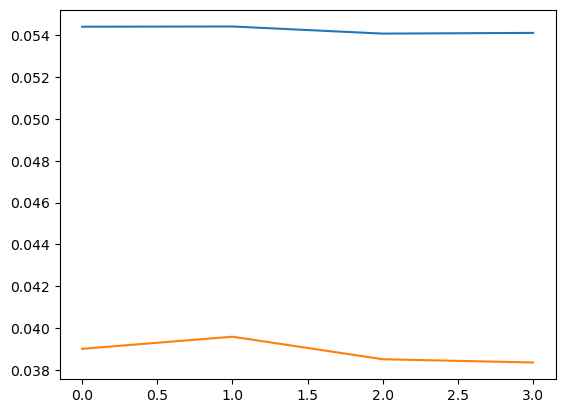

In [ ]:
plt.plot(10* np.array(trainer.losses['decode-only']['eval']['diffusion']), label='diffusion')
plt.plot(trainer.losses['decode-only']['eval']['mse'])

In [ ]:
self.training_configs['decode-onlya'].loss_weight_params

{'strategy': 'gradnorm',
 'lr': 0.025,
 'alpha': 0.5,
 'gradnorm_layer': -2,
 'T': 3.0,
 'update_interval': 20,
 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0},
 'loss_schedule': {'mse': [0, 100],
  'distribution': [0, 100],
  'diffusion': [0, 100]}}

In [ ]:
trainer.lw_history

defaultdict(list,
            {'mse-only': [[3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0]],
             'decode-only': [[0.27272728085517883, 2.7272727489471436],
              [0.27272728085517883, 2.7272727489471436],
              [0.27618083357810974, 2.7238190174102783],
              [0.2794596552848816, 2.7205402851104736],
              [0.28268563747406006, 2.7173142433166504],
              [0.28592178225517273, 2.714078187942505],
              [0.2892145812511444, 2.710785150527954]],
             'encode-decode': [[0.27272728085517883, 2.7272727489471436],
              [0.27272728085517883, 2.7272727489471436],
              [0.27651503682136536, 2.723484992980957],
              [0.28023722767829895, 2.7197628021240234],
              [0.28398510813713074, 2.716014862060547],
              [0.28781643509864807, 2.712183713912964],
              [0.291

In [ ]:
self.tconfigs = self.training_configs

In [ ]:
self = trainer

master_dict = {'data_config': dataclasses.asdict(self.dconfig)}
master_dict['indices'] = [i.tolist() for i in self.indices]
for run_id in self.run_ids:
    master_dict[run_id] = {
        'model_config': dataclasses.asdict(self.mconfigs[run_id]),
        'training_config': dataclasses.asdict(self.tconfigs[run_id]),
        #'optimizer': self.optimizers[run_id].state_dict(),
        "losses": self.losses[run_id],
        "gradients": self.gradients[run_id],
        "L0": self.L0[run_id],
        
    }

In [ ]:
with open(self.log_file_path, 'w') as f:
    json.dump(master_dict, f)

In [ ]:
self.log_file_path

'/mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json'

In [ ]:
def diffusion_loss(trainer, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = trainer.training_configs[run_id]
    scheduler = trainer.schedulers[run_id]
    image_dim = 2 if "2" in tconfig.diffusion_strategy else 1
    y_image = trainer._make_image(y_hat, image_dim)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        og = xt.detach().clone()
        dists = []
        dist = torch.nn.MSELoss()
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = trainer.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
                dists.append(dist(og, xt).item())
        return(xt, dists)
    if "encode" in tconfig.diffusion_strategy:
        y_image = encode(y_image)
    y_image_denoised, dists = decode(y_image)
    return(tru.image_loss(tconfig)(y_image_denoised, y_image), dists)

In [ ]:
l, rdists = diffusion_loss(trainer, y, run_id)
l

tensor(0.0407, device='cuda:0')

In [ ]:
l, fdists = diffusion_loss(trainer, y_hat, run_id)
l

tensor(0.0420, device='cuda:0', grad_fn=<MseLossBackward0>)

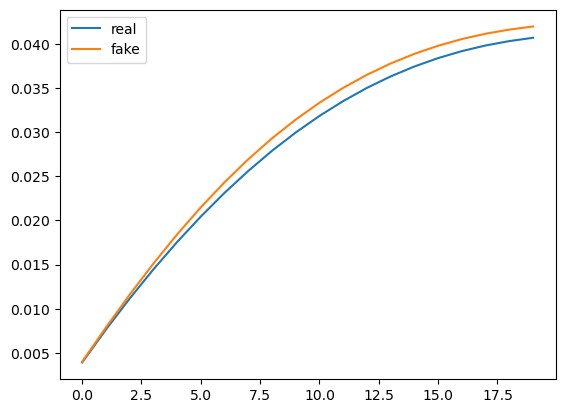

In [ ]:
plt.plot(rdists, label="real")
plt.plot(fdists, label="fake")
plt.legend()

In [ ]:
unet2d = tru.load_diffusion_model()

In [ ]:
run2d = evals.Run("diffusion_hp_search", "lr-explore", climsim_run = False, cid='best')
trainer = run2d.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
losses, self.loss_weights[run_id]

(tensor([1.5882e-02, 4.3194e+03, 4.1961e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([2.0310e-01, 1.6816e-04, 2.7967e+00], device='cuda:0',
        requires_grad=True))

In [ ]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [ ]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [ ]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [ ]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [ ]:
x, y = next(iter(trainer.dataloaders['train']))

In [ ]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [ ]:
params[0] == after_params[0]

In [ ]:
after_params[0]

In [ ]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [ ]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## VAE Training

In [ ]:
x = torch.tensor([7.0, 1, 5, 6, 2, 7, 2, 9]).to(device)
y = x * x
y.shape

model = torch.nn.Sequential(
    torch.nn.Linear(8, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 8),
).to(device)
optim = torch.optim.Adam(model.parameters())

losses = []
loss = 10
loss_fn = torch.nn.MSELoss()
step = 0
while loss > 0.1:
    pred = model(x)
    loss = loss_fn(pred, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    losses.append(loss.item())
    step += 1

In [ ]:
step, len(losses)

(866, 866)

# Training behavior  - Diffusion

In [ ]:
def create_optimizer(model, tconfig):
    kwargs = {'lr' : tconfig.learning_rate_params.get("learning_rate")}
    opt = tconfig.optimizer.lower()
    if "adam" in opt:
        ocls = torch.optim.Adam
        kwargs['betas'] = tconfig.learning_rate_params.get("betas", (0.9, 0.999))
    else: # defaults to SGD
        ocls = torch.optim.SGD
    if "groups" in opt and tconfig.param_groups:
        param_groups = []
        for group_cfg in tconfig.param_groups:
            if "exclude" in group_cfg['select_method']:
                kwargs['params'] = [p for n, p in model.named_parameters() if group_cfg['keyword'] not in n]
            elif "include" in group_cfg['select_method']:
                kwargs['params'] = [p for n, p in model.named_parameters() if group_cfg['keyword'] in n]
            else:
                raise ValueError(f"Invalid select_method: {group_cfg['select_method']}")
            kwargs.update( {k:v for k, v in group_cfg.items() if k not in ['select_method', 'keyword']} )
            param_groups.append(copy.deepcopy(kwargs))
        return ocls(param_groups)
    return ocls(model.parameters(), **kwargs)

In [ ]:
tc = TrainingConfig('a', 'b')
tc.optimizer = 'adam-groups'

tc.learning_rate_params['learning_rate'] = 1e-3
tc.learning_rate_params['betas'] = (0.9, 0.92)

In [ ]:
tc.param_groups = [
    dict(select_method='exclude', keyword='scale_output'),
    dict(select_method='include', keyword='scale_output', lr=1e-1, weight_decay=0.0),
]

#optimizer = torch.optim.Adam([
#    {"params" : [p for n, p in model.named_parameters() if 'scale_output' not in n], "lr" : 0.0001},
#    {"params" : [model.scale_output.weight], "lr" : 1e-1, "weight_decay" : 0.0},
#])

o, g = create_optimizer(model, tc)

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [ ]:
from diffusionsim.evaluations import *

In [ ]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [ ]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [ ]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
distribution_loss(trainer, y_hat, y, tconfigs[0], 0) # nan? 

In [ ]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [ ]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [ ]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [ ]:
from diffusionsim.models import *

In [ ]:
source = "local-vzarr"
data_vars = 'v1'
in_notebook = True
shuffle_indices = False
dataset_type = "climsim_diffusion1d"
batch_size = 16
use_tendencies = False


In [ ]:
dconfig = tru.my_dconfig(source, data_vars, in_notebook, shuffle_indices, dataset_type, batch_size, use_tendencies)
dconfig.train_test_split = [0.001]
dconfig.phases = ['train']


In [ ]:
dataloaders, indices = data.load_dataloaders(dconfig, log=False)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [ ]:
dl = dataloaders[0]
ds = dl.dataset
dutils = ds.dutils
y = next(iter(dl))

In [ ]:
scheduler = models.configs.SchedulerParams(prediction_type = "v_prediction")

scheduler

SchedulerParams(scheduler_type='ddpm',
                num_train_timesteps=100,
                beta_schedule='linear',
                clip_sample=False,
                clip_sample_range=4.0,
                beta_end=0.02,
                prediction_type='v_prediction',
                scheduler_inference_steps=100)


In [ ]:
pprint(mconfig)

UNetParamsNV(model_type='unet1d-nv',
             num_vars_profile=2,
             num_vars_scalar=4,
             num_vars_profile_out=2,
             num_vars_scalar_out=8,
             diffusion_mode=True,
             model_channels=64,
             channel_mult=[1, 2, 2, 2],
             num_blocks=3,
             attn_resolutions=[16],
             conditioning_resolutions={8: ['timesteps'],
                                       16: ['timesteps'],
                                       32: ['timesteps'],
                                       64: ['timesteps']},
             dropout=0.05,
             output_scale_type='scale-only',
             kernel_size=3,
             time_embedding_dim=32)


In [ ]:
plt.plot(torch.sqrt(scheduler.alphas_cumprod.cpu()))

AttributeError: 'SchedulerParams' object has no attribute 'alphas_cumprod'

In [ ]:
y.mean(), y.std()

(tensor(-0.0701), tensor(1.6746))

In [ ]:
x0 = y[::3][::5][::7][:16].to(device)
eps = torch.randn(x0.shape, device=device)
timesteps = torch.full((x0.shape[0],), 70, device=device, dtype=torch.long)
xt = scheduler.add_noise(x0, eps, timesteps)

In [ ]:
alpha_bar = scheduler.alphas_cumprod[timesteps].to(device)
print("alpha bar   ", alpha_bar[0])
while len(alpha_bar.shape) < len(x0.shape):
    alpha_bar = alpha_bar.unsqueeze(-1)
vt = torch.sqrt(alpha_bar) * eps - torch.sqrt(1 - alpha_bar) * x0
assert torch.allclose(vt, scheduler.get_velocity(x0, eps, timesteps))
vt.shape
torch.sqrt(alpha_bar[0,0]), torch.sqrt(1 - alpha_bar[0,0]), 

alpha bar    tensor(0.6011, device='cuda:0')


(tensor([0.7753], device='cuda:0'), tensor([0.6316], device='cuda:0'))

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/evaluations.py:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


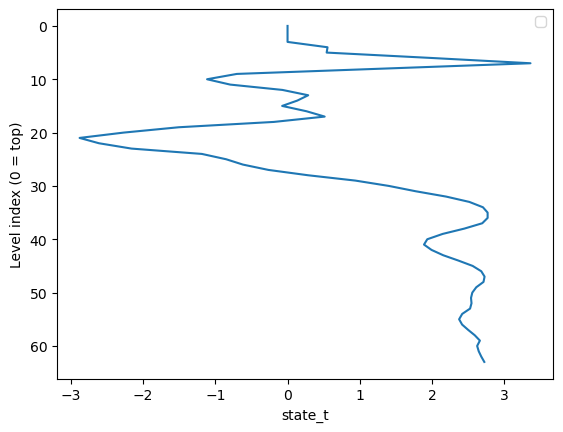

In [ ]:
i = 4
evals.plot_profile(x0[i], var_index=0, ds=ds)

['vt', 'x0']


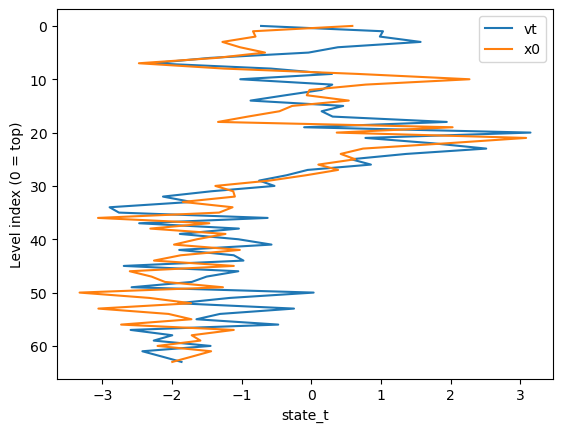

In [ ]:
evals.plot_profile(torch.cat([vt[i:i+1], -xt[i:i+1]], axis=0), var_index=0, labels='vt x0'.split(), ds=ds)

In [ ]:
target, target_name = vt, 'vt'

In [ ]:
unet = mconfig.unet
unet.block_out_channels = (32, 32, 64) #if data_vars == "v1" else None
unet.down_block_types = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D") #if data_vars=="v1" else None
unet.up_block_types = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D") #if data_vars=="v1" else None
unet.in_channels = 10 if data_vars == "v1" else 14
unet.out_channels = 10 if data_vars == "v1" else 14

In [ ]:
model.config.out_channels

10

In [ ]:
model = tru.ModelLens(pass_config(ClimsimUNet1DModel, mconfig.unet).to(device))

skeet


In [ ]:
from dataclasses import dataclass, asdict, field
import inspect

In [ ]:
#TODO : try zeuyan unet to see of lower loss floor
model = unet = self = tru.ModelLens(ClimsimUnet(
    num_vars_profile=len([v for v in dutils.input_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.input_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    diffusion_mode = True,
    model_channels= 64,
    kernel_size=3,
    channel_mult = [1, 8, 8, 8],
    attn_resolutions=[], conditioning_resolutions={64:[], 32:[], 16 : [], 8 : []},
    dropout=0.0, 
    output_scale_type='scale-only'
).to(device))

In [ ]:
len(dutils.target_vars)

10

In [ ]:
#import dataclasses
#md = dataclasses.asdict(mconfig)
#md['unet'].update({"diffusion_mode" : True})

In [ ]:
model.get_param(-1), model.param_names[-1]

(Parameter containing:
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
        requires_grad=True),
 'scale_output.weight')

In [ ]:
[p for n, p in model.named_parameters() if "scale_output" in n]

[Parameter containing:
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
        requires_grad=True)]

In [ ]:
loss = 10
loss_fn = torch.nn.MSELoss()
#trainer = self = DiffusionTrainerTest(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id)
optimizer = torch.optim.Adam([
    {"params" : [p for n, p in model.named_parameters() if 'scale_output' not in n], "lr" : 0.0001},
    {"params" : [model.scale_output.weight], "lr" : 1e-1, "weight_decay" : 0.0},
])
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.9)
losses, lrs = [], []
step = 0
while loss > 0.01 and step < 1000:
    pred = model(xt, timesteps).sample
    loss = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    lr_scheduler.step()
    lrs.append(lr_scheduler.get_last_lr()[0])
    step += 1 
print("done at step", step, "loss", loss)

done!


In [ ]:
model.scale_output.weight

Parameter containing:
tensor([ 2.6872,  1.3975,  1.0245,  1.5222,  1.1409, -0.4317,  1.1826,  0.9997,
         1.0920,  0.9296], device='cuda:0', requires_grad=True)

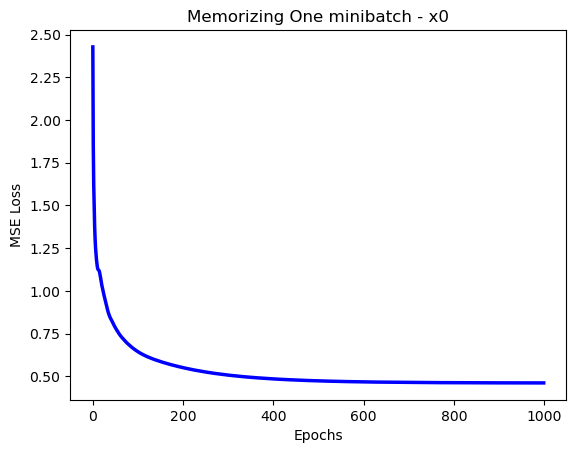

In [ ]:
plt.plot(losses, color='blue', linewidth=2.50)
plt.title("Memorizing One minibatch - x0")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
pred = model(xt, timesteps)
pred = model(xt, timesteps).sample

In [ ]:
loss = loss_fn(pred, target)
loss.backward()
loss

tensor(0.4610, device='cuda:0', grad_fn=<MseLossBackward0>)

In [ ]:
model.get_param(-1), model.get_param(-1).grad

(Parameter containing:
 tensor([ 2.6872,  1.3975,  1.0245,  1.5222,  1.1409, -0.4317,  1.1826,  0.9997,
          1.0920,  0.9296], device='cuda:0', requires_grad=True),
 tensor([-0.0027, -0.0013, -0.0034, -0.0019, -0.0027,  0.0008, -0.0015, -0.0012,
         -0.0010, -0.0034], device='cuda:0'))

In [ ]:
eps = 1e-8
num = (pred * target).sum(dim=(0,2))          # shape [C]
den = (pred * pred).sum(dim=(0,2)) + eps     # shape [C]
g_init = (num / den).detach()                # shape [C]
g_init

tensor([1.0078, 1.0038, 1.0155, 1.0031, 1.0136, 1.0059, 1.0087, 1.0050, 1.0059,
        1.0200], device='cuda:0')

In [ ]:
num / den

tensor([1.0078, 1.0038, 1.0155, 1.0031, 1.0136, 1.0059, 1.0087, 1.0050, 1.0059,
        1.0200], device='cuda:0', grad_fn=<DivBackward0>)

In [ ]:
def plot_profile(data, var_index=None, ax=None, title='', ds=None, **kwargs):
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and 5 <= data.shape[0] <= 16):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        print(data.shape)
        im = ax.plot(data, levels, **kwargs)
    else:
        if 'labels' in kwargs and len(kwargs['labels']) == len(data):
            labels = kwargs['labels']
            print(labels)
        for i, profile in enumerate(data): 
            im = ax.plot(profile, levels, label=labels[i])
    plt.legend()
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])
    return(im)

['pred', 'target']


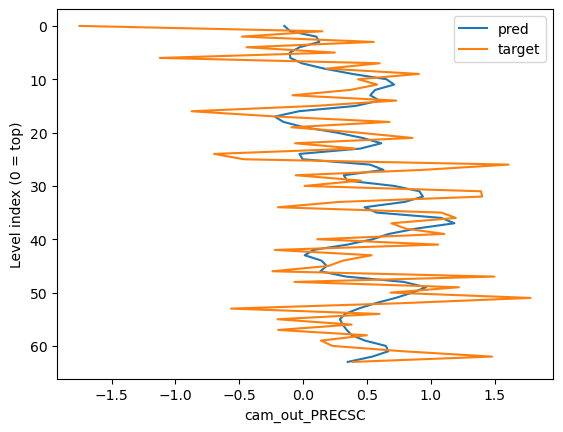

In [ ]:
plot_profile(torch.cat([pred[0:1], target[0:1]], dim=0), var_index=4, ds=ds, labels='pred target'.split())

0 tensor(0.3454, device='cuda:0') tensor(2.6983, device='cuda:0')
1 tensor(0.3917, device='cuda:0') tensor(1.3919, device='cuda:0')
2 tensor(0.4863, device='cuda:0') tensor(1.0665, device='cuda:0')
3 tensor(0.4095, device='cuda:0') tensor(2.7556, device='cuda:0')
4 tensor(0.4860, device='cuda:0') tensor(1.0450, device='cuda:0')
5 tensor(0.5635, device='cuda:0') tensor(0.6623, device='cuda:0')
6 tensor(0.5097, device='cuda:0') tensor(1.0354, device='cuda:0')
7 tensor(0.4537, device='cuda:0') tensor(1.0563, device='cuda:0')
8 tensor(0.4561, device='cuda:0') tensor(0.9197, device='cuda:0')
9 tensor(0.5082, device='cuda:0') tensor(0.9069, device='cuda:0')


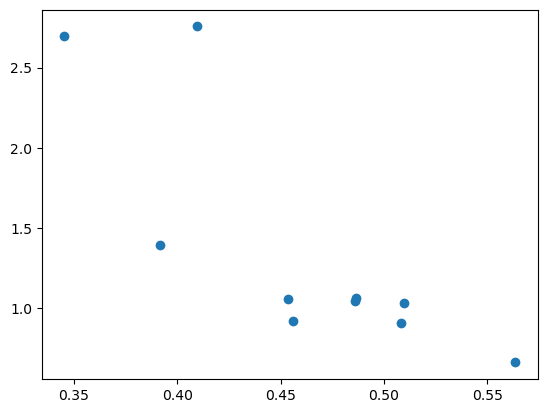

In [ ]:
losses = []
variances = []
with torch.no_grad():
    for channel in range(x0.shape[1]):
        pc = pred[:,channel]
        tc = target[:,channel]
        print(channel, loss_fn(pc, tc), torch.var(tc))
        losses.append(loss_fn(pc, tc).item())
        variances.append(torch.var(tc).item())

plt.plot(losses, variances, 'o')


In [ ]:
gain = torch.ones(10, requires_grad=False)
gain[0] = 2
gain = nn.Parameter(gain).to(device)
gain_optim = torch.optim.Adam([gain], lr=0.001)
gain

In [ ]:
#fig, ax = plt.subplots(1, 1)
im1 = plot_profile(torch.cat([pred[i:i+1], target[i:i+1]/2], dim=0), 4, labels=f'prediction {target_name}'.split())
plt.title(f"{target_name} Prediction at T=20")
plt.show()

In [ ]:
losses = np.array(losses)

np.corrcoef(losses, var)

plt.plot(losses, var, 'o')

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)

# Scratch Work

## Unet CUDA In Memory

In [4]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "test_memory"
base_dir = os.path.join(exp_dir, exp_id)
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True
dataset_type="climsim"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
dconfig = tru.my_dconfig(
	source="local_vzarr",
	data_vars='v1',
	in_notebook=True,
	shuffle_indices=False,
	dataset_type="climsim_diffusion1d",
	batch_size=128,
	use_tendencies=False,
)

In [8]:
dconfig.dataset_type
dconfig.phases = ['train']
dconfig.train_test_split = [0.001]

In [9]:
dataloaders, indices = data.load_dataloaders(dconfig)
ds = dataloaders[0].dataset
y = ds[0].to(device)
y.shape

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


torch.Size([49152, 10, 64])

In [10]:
scheduler = models.SchedulerParams(
    model_type = "ddpm-scheduler",
    beta_schedule = "linear",
    clip_sample = False,
    clip_sample_range = 4.0,
    beta_end = 0.02,
    prediction_type = "v_prediction"
)

In [12]:
num_blocks = [3, 3, 3, 3, 3, 3]
kernel_sizes = [3, 3, 3, 5, 5, 5]
block_out_channels = [
	(64, 128, 128, 128),
	(64, 128, 256, 256),
	(64, 256, 512, 512),
	(64, 128, 128, 128),
	(64, 128, 256, 256),
	(64, 256, 512, 512)
]
mconfigs = []
tconfigs = []
num_models = len(block_out_channels)
lettering = "abcdefghijklm"
for i in range(num_models):
	mconfig = tru.my_unet(
		block_channels = block_out_channels[i], 
		utype="nv",
		data_vars="v1",
		image_dim=1,
		kernel_size=kernel_sizes[i],
		num_blocks=3
	)
	mconfigs.append(mconfig)
	t = tru.TrainingConfig(exp_id=exp_id, run_id="mod"+lettering[i], optimizer='adam-groups')
	t.param_groups = [
		dict(select_method='exclude', keyword='scale_output', lr=1e-3),
		dict(select_method='include', keyword='scale_output', lr=1e-1, weight_decay=0.0),
	]
	tconfigs.append(t)

### Running it

In [13]:
import diffusers
from diffusionsim.models import pass_config, ModelLens
class DiffusionTrainer(trainers.AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, scheduler):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id)
        del self.models
        self.models = {}
        for i, run_id in enumerate(self.run_ids):
            self.models[run_id] = models.ModelLens(pass_config(ClimsimUnet, mconfigs[i]))
        self.scheduler = scheduler if isinstance(scheduler, diffusers.SchedulerMixin) else models.load_model(scheduler, apply_lens=False)
    
    def _run_batch(self, batch, step):
        images = batch.to(self.device)
        if(self.log):
            t0 = tru.log_event("run-batch start")
        batch_losses = {}
        for run_id in self.run_ids:
            print(run_id)
            print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
            print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
            model, optimizer = self.models[run_id].to(self.device), self.optimizers[run_id]
            tconfig, lr_scheduler = self.training_configs[run_id], self.lr_schedulers[run_id]
            noises = torch.randn(images.shape, device=self.device)
            timesteps = torch.randint(0, tconfig.max_T_sample, size=(images.shape[0],), device=self.device, dtype=torch.int64)
            xt = self.scheduler.add_noise(images, noises, timesteps)
            if self.scheduler.config.prediction_type == 'v_prediction':
                target = self.scheduler.get_velocity(images, noises, timesteps)
            else:
                target = noises
            scaler = torch.amp.GradScaler('cuda')
            with torch.amp.autocast('cuda'):
                print(xt.shape, timesteps.shape)
                pred = model(xt, timesteps.flatten()).sample
                loss = self.loss_fn(pred, target)
            if(self.current_phase == 'train'):
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                if(tconfig.clip_gradients):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if(lr_scheduler is not None):
                    lr_scheduler.step()
            batch_losses[run_id] = loss.item()

            model.to("cpu")
            #move_optimizer(optimizer, "cuda")
            del pred, loss, xt, target, noises, timesteps
            torch.cuda.empty_cache()
            print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
            print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
        if(self.log):
            tru.log_event("run-batch end", duration=time.time() - t0, **batch_losses)
        return(batch_losses)

    def log_step(self, batch_losses, step):
        if(step % self.bli == 0 or step+1 == len(self.dataloaders[self.current_phase])):
            for run_id in self.run_ids:
                self.losses.setdefault(run_id, defaultdict(list))[self.current_phase].append(batch_losses[run_id])

        if ((step+1) % self.ckpt_interval == 0 and self.current_phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
    def _log_epoch_info():
        pass

In [22]:
trainer = DiffusionTrainer(
    dataloaders, indices, mconfigs, tconfigs, base_dir, "mod", scheduler
)

In [23]:
get = lambda i : trainer.models[trainer.run_ids[i]]
model = get(0)
model.diffusion_mode

True

In [25]:
trainer._run_batch(y, 0)

moda
Allocated: 120.00 MB
Reserved:  120.00 MB
torch.Size([49152, 10, 64]) torch.Size([49152])
torch.Size([49152, 10, 64])
torch.Size([49152, 10, 64]) a
torch.Size([49152, 10, 68]) b
64_conv
torch.Size([49152, 10, 68]) Conv1d() 10
64_block0
torch.Size([49152, 64, 68]) UNetBlock_noatten(
  (embedding_blocks): ModuleDict(
    (timesteps): UNetCondEmbedding(
      (emb_proj): GaussianFourierProjection()
      (emb_linear): Linear()
    )
  )
  (norm0): GroupNorm()
  (conv0): Conv1d()
  (norm1): GroupNorm()
  (conv1): Conv1d()
) 64
64_block1
torch.Size([49152, 64, 68]) UNetBlock_noatten(
  (embedding_blocks): ModuleDict(
    (timesteps): UNetCondEmbedding(
      (emb_proj): GaussianFourierProjection()
      (emb_linear): Linear()
    )
  )
  (norm0): GroupNorm()
  (conv0): Conv1d()
  (norm1): GroupNorm()
  (conv1): Conv1d()
) 64
64_block2
torch.Size([49152, 64, 68]) UNetBlock_noatten(
  (embedding_blocks): ModuleDict(
    (timesteps): UNetCondEmbedding(
      (emb_proj): GaussianFourierPro

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


16_block1
torch.Size([49152, 128, 17]) UNetBlock_atten(
  (embedding_blocks): ModuleDict(
    (timesteps): UNetCondEmbedding(
      (emb_proj): GaussianFourierProjection()
      (emb_linear): Linear()
    )
  )
  (norm0): GroupNorm()
  (conv0): Conv1d()
  (norm1): GroupNorm()
  (conv1): Conv1d()
  (norm2): GroupNorm()
  (qkv): Conv1d()
  (proj): Conv1d()
  (attentionop): ScriptableAttentionOp()
) 128
16_block2
torch.Size([49152, 128, 17]) UNetBlock_atten(
  (embedding_blocks): ModuleDict(
    (timesteps): UNetCondEmbedding(
      (emb_proj): GaussianFourierProjection()
      (emb_linear): Linear()
    )
  )
  (norm0): GroupNorm()
  (conv0): Conv1d()
  (norm1): GroupNorm()
  (conv1): Conv1d()
  (norm2): GroupNorm()
  (qkv): Conv1d()
  (proj): Conv1d()
  (attentionop): ScriptableAttentionOp()
) 128
8_down
torch.Size([49152, 128, 17]) UNetBlock_noatten(
  (norm0): GroupNorm()
  (conv0): Conv1d()
  (norm1): GroupNorm()
  (conv1): Conv1d()
  (skip): Conv1d()
) 128
8_block0
torch.Size([49152

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.50 GiB. GPU 0 has a total capacity of 79.20 GiB of which 1004.62 MiB is free. Including non-PyTorch memory, this process has 78.21 GiB memory in use. Of the allocated memory 77.25 GiB is allocated by PyTorch, and 304.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [111]:
mconfigs[0]

UNetParamsNV(model_type='unet1d-nv', num_vars_profile=2, num_vars_scalar=4, num_vars_profile_out=2, num_vars_scalar_out=8, diffusion_mode=True, model_channels=64, channel_mult=[1, 2, 2, 2], num_blocks=3, attn_resolutions=[16], conditioning_resolutions={64: ['timesteps'], 32: ['timesteps'], 16: ['timesteps'], 8: ['timesteps']}, dropout=0.05, output_scale_type='scale-only', kernel_size=3, time_embedding_dim=32)

### Cuda Functions

In [37]:
import gc
def report_live_cuda_tensors():
    total = 0
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) and obj.is_cuda:
                size_mb = obj.element_size() * obj.nelement() / 1024**2
                total += size_mb
                print(f"Tensor: {type(obj)} {tuple(obj.shape)} {obj.dtype} "
                      f"{size_mb:.2f} MB, requires_grad={obj.requires_grad}")
        except Exception:
            pass
    print(f"Total from gc scan: {total:.2f} MB")

#del model, images, optimizer, xt, noises, timesteps, target
def empty_cuda():
    import gc
    gc.collect()

    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
report_live_cuda_tensors()

Tensor: <class 'torch.Tensor'> (49152, 124) torch.float32 23.25 MB, requires_grad=False
Tensor: <class 'torch.Tensor'> (49152, 128) torch.float32 24.00 MB, requires_grad=False


/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/__init__.py:1021: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


Total from gc scan: 47.25 MB


In [ ]:
def move_optimizer(optimizer, device):
    for s in optimizer.state.values():
        for k, v in s.items():
            if torch.is_tensor(v):
                s[k] = v.to(device)

In [102]:
print("peak allocated: ", torch.cuda.max_memory_allocated() / 1024**2, "MB")
print("peak reserved: ", torch.cuda.max_memory_reserved() / 1024**2, "MB")

peak allocated:  96.0 MB
peak reserved:  98.0 MB


In [107]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

Allocated: 24.00 MB
Reserved:  98.00 MB


In [104]:

print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

Allocated: 48.00 MB
Reserved:  98.00 MB


In [ ]:
torch.cuda.reset_peak_memory_stats()

In [ ]:
def profile_pass(model, with_grad=False):
	scaler = torch.amp.GradScaler('cuda')
	with torch.profiler.profile(
		activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
		profile_memory=True,
		record_shapes=True
	) as prof:
		with torch.no_grad():
			model = model.to(device)
			pred = model(xt, timesteps.flatten()).sample
		return(prof.key_averages().table(sort_by="self_cuda_memory_usage", row_limit=20))

## Model Definitions

In [15]:
from diffusionsim.models.conv_blocks import *
import einops
import physicsnemo as modulus
from collections import OrderedDict
from typing import Any, Dict, List, Optional, Tuple

In [16]:
class UNetCondEmbedding(torch.nn.Module):
    def __init__(
        self, 
        num_channels: int, 
        embed_dim: int = 0, 
        embedding_type: str = "",
        emb_method: str = "concat", 
        activation: str = "",
        projection_method: str = "linear",
        **kwargs
    ):
        super().__init__()
        self.act_fn = get_activation(activation) if activation else None
        self.num_channels = num_channels
        self.embed_dim = embed_dim
        self.emb_method = emb_method

        # create embedding
        # create a 385x8 trainable weight embedding for the input
        match embedding_type:
            case "fourier" | "gaussian":
                assert embed_dim % 2 == 0, f"`time_embed_dim` should be divisible by 2, but is {embed_dim}."
                self.emb_proj = diffusers.models.embeddings.GaussianFourierProjection(embedding_size=embed_dim // 2, set_W_to_weight=False, log=False)
            case "positional":
                self.emb_proj = diffusers.models.embeddings.Timesteps(embed_dim, flip_sin_to_cos=False, downscale_freq_shift=0.0)
            case "discrete_embedding":
                self.emb_proj = torch.nn.Embedding(num_embeddings=num_channels, embedding_dim=embed_dim)
            case "sinusoidal":
                raise NotImplementedError("Sinusoidal embedding not implemented")
            case _:
                self.emb_proj = None
        """
        self.affine = Linear(in_features=embed_dims, out_features=out_channels * (2 if adaptive_scale else 1),  **init)
        # params = self.affine(emb).unsqueeze(2).to(x.dtype)
        # if self.adaptive_scale:
        #     scale, shift = params.chunk(chunks=2, dim=1)
        #     x = F.silu(torch.addcmul(shift, self.norm1(x), scale + 1))
        # else:
        #     x = F.silu(self.norm1(x.add_(params)))
        """

        # define how embedding is injected into the sample        
        match emb_method:
            case "concat":
                pass
            case "add":
                if not embed_dim:
                    embed_dim = num_channels
                if projection_method == "linear":
                    self.emb_linear = Linear(embed_dim, num_channels)
                elif projection_method == "mlp":
                    act_fn = self.act_fn if self.act_fn else torch.nn.SiLU()
                    self.emb_linear = torch.nn.Sequential(Linear(embed_dim, embed_dim), act_fn, Linear(embed_dim, num_channels))
                else:
                    assert embed_dim == num_channels, "no projection specified but channel dimension mismatch"
                    self.emb_linear = None
            case t if "attention" in t or "attn" in t:
                raise NotImplementedError("Attention embedding not implemented")
            case _:
                raise ValueError(f"Embedding method {emb_method} not supported")
    
    def forward(self, sample, embed):
        assert embed.shape[0] == sample.shape[0], "Batch size of sample and embed must match"
        self.sample_dims = sample.shape
        if self.act_fn:
            embed = self.act_fn(embed)
        
        if self.emb_proj:
            embed = self.emb_proj(embed)
        
        match self.emb_method:
            case "concat":
                pattern = 'b e -> b e ' + ' '.join([f'd{i}' for i in range(len(sample.shape) - 2)])
                embed = einops.repeat(embed, pattern, **{f'd{i}': s for i, s in enumerate(sample.shape[2:])})
                return torch.cat([sample, embed], dim=1)
            case "add":
                if self.emb_linear is not None:
                    embed = self.emb_linear(embed)
                embed = einops.rearrange(embed, "b c -> b c" + " 1" * (len(self.sample_dims) - len(embed.shape)))
                return sample + embed
            case t if "attention" in t or "attn" in t:
                raise NotImplementedError("Attention embedding not implemented")
            case _:
                raise ValueError(f"Embedding method {self.emb_method} not supported")


In [18]:
class UNetBlock(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        attention: bool = False,
        use_scriptable_attention: bool = True,
        num_heads: int = None,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.embedding_blocks = nn.ModuleDict(embedding_blocks) if embedding_blocks is not None else None
        self.num_heads = (
            0
            if not attention
            else num_heads
            if num_heads is not None
            else out_channels // channels_per_head
        )
        self.dropout = dropout
        self.skip_scale = skip_scale
        self.adaptive_scale = adaptive_scale

        self.norm0 = GroupNorm(num_channels=in_channels, eps=eps)
        self.conv0 = Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel=kernel_size,
            up=up,
            down=down,
            resample_filter=resample_filter,
            **init,
        )
        self.norm1 = GroupNorm(num_channels=out_channels, eps=eps)
        self.conv1 = Conv1d(
            in_channels=out_channels, out_channels=out_channels, kernel=kernel_size, **init_zero
        )

        self.skip = None
        if out_channels != in_channels or up or down:
            kernel = 1 if resample_proj or out_channels != in_channels else 0
            self.skip = Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel=kernel,
                up=up,
                down=down,
                resample_filter=resample_filter,
                **init,
            )

        if self.num_heads:
            self.norm2 = GroupNorm(num_channels=out_channels, eps=eps)
            self.qkv = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels * 3,
                kernel=1,
                **(init_attn if init_attn is not None else init),
            )
            self.proj = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel=1,
                **init_zero,
            )
            if use_scriptable_attention:
                self.attentionop = ScriptableAttentionOp()
    
    def forward(self, x, conditioning_signals={}):
        skip_res = self.skip(x) if self.skip is not None else x
        x = self.conv0(F.silu(self.norm0(x)))
        x = self.norm1(x)
        if self.embedding_blocks is not None:
            for embed_name, embedding in conditioning_signals.items():
                if embed_name in self.embedding_blocks:
                    x = self.embedding_blocks[embed_name](x, embedding)
                else:
                    print(f"Warning: {embed_name} not found in embedding_blocks")
            
        x = self.conv1(
            torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        )
        x = x.add_(skip_res)
        x = x * self.skip_scale

        if self.num_heads:  # if using attention
            def attention_forward(x_in):
                q, k, v = (
                    self.qkv(self.norm2(x_in))
                    .reshape(
                        x_in.shape[0] * self.num_heads, x_in.shape[1] // self.num_heads, 3, -1
                    )
                    .unbind(2)
                )
                if self.attentionop is not None:
                    w = self.attentionop(q, k)
                else:
                    w = AttentionOp.apply(q, k)
                a = torch.einsum("nqk,nck->ncq", w, v)
                return self.proj(a.reshape(*x_in.shape)).add_(x_in)
            # wrap attention in checkpoint
            x = torch.utils.checkpoint.checkpoint(attention_forward, x)
            x = x * self.skip_scale
        return x


In [19]:
class UNetBlock_noatten(UNetBlock):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        attention: bool = False,
        num_heads: int = None,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
    ):
        super().__init__(
            in_channels, out_channels, embedding_blocks, kernel_size,
            up, down,
            False, False, None, channels_per_head,
            dropout, skip_scale,
            eps, resample_filter, resample_proj, adaptive_scale,
            init, init_zero, None)

class UNetBlock_atten(UNetBlock):

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        embedding_blocks: OrderedDict[str, UNetCondEmbedding] = None,
        emb_channels: int = 0,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        num_heads: int = 1,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
        attention: bool = True,
    ):
        super().__init__(
            in_channels, out_channels, embedding_blocks, kernel_size,
            up, down,
            True, True, num_heads, channels_per_head,
            dropout, skip_scale, eps, resample_filter, resample_proj, adaptive_scale,
            init, init_zero, init_attn)


In [20]:
@dataclasses.dataclass
class ClimsimUnetMetaData(modulus.ModelMetaData):
    name: str = "ClimsimUnet"
    # Optimization
    jit: bool = True
    cuda_graphs: bool = True
    amp_cpu: bool = True
    amp_gpu: bool = True

In [ ]:
class ClimsimUnet(modulus.Module):
    def __init__(
		self,
		num_vars_profile: int,
		num_vars_scalar: int, 
		num_vars_profile_out: int,
		num_vars_scalar_out: int,
		diffusion_mode: bool,
		seq_resolution: int = 64,
		model_channels: int = 128,
		channel_mult: List[int] = [1, 2, 2, 2],
		num_blocks: int = 4,
		attn_resolutions: List[int] = [16],
		conditioning_resolutions: Dict[int, List[str]] = {
			64: ["timesteps"],
			32: ["timesteps"],
			16: ["timesteps"],
			8: ["timesteps"],
			4: ["timesteps"],
			2: ["timesteps"],
			1: ["timesteps"],
		},
		dropout: float = 0.10,
		encoder_type: str = "standard",
		decoder_type: str = "standard",
		resample_filter: List[int] = [1, 1],
		n_model_levels: int = 60,
		# qinput_prune=False, 
		output_prune=False, 
		strato_lev=12,
		time_embedding_dim: int = 32,
		loc_embedding: bool = False,
		loc_embedding_dim: int = 8,
		skip_conv: bool = False,
		kernel_size: int = 3,
		output_scale_type: str = '',
	):
        super().__init__(meta=ClimsimUnetMetaData())
        # check if hidden_dims is a list of hidden_dims
        if diffusion_mode:
            self.num_vars_profile = num_vars_profile_out
            self.num_vars_scalar = num_vars_scalar_out
        else:
            self.num_vars_profile = num_vars_profile
            self.num_vars_scalar = num_vars_scalar
        
        self.num_vars_profile_out = num_vars_profile_out
        self.num_vars_scalar_out = num_vars_scalar_out
        self.diffusion_mode = diffusion_mode
        self.model_channels = model_channels

        self.in_channels = self.num_vars_profile + self.num_vars_scalar # + 7 # +(8-1)=7 for the location embedding
        self.out_channels = num_vars_profile_out + num_vars_scalar_out
        # print('1: out_channels', self.out_channels)

        # valid_encoder_types = ["standard", "skip", "residual"]
        valid_encoder_types = ["standard"]
        assert encoder_type in valid_encoder_types, f"Invalid encoder_type: {encoder_type}. Must be one of {valid_encoder_types}."

        # valid_decoder_types = ["standard", "skip"]
        valid_decoder_types = ["standard"]
        assert decoder_type in valid_decoder_types, f"Invalid decoder_type: {decoder_type}. Must be one of {valid_decoder_types}."
        self.conditioning_resolutions = conditioning_resolutions
        self.time_embedding_dim = time_embedding_dim
        self.use_loc_embedding = loc_embedding
        if loc_embedding:
            assert loc_embedding_dim > 0, f"Location embedding dimension {loc_embedding_dim} is not valid" 
            self.loc_embedding = UNetCondEmbedding(
                    num_channels=384, embed_dim=loc_embedding_dim, embedding_type="discrete_embedding", emb_method="concat"
            )
            self.in_channels += loc_embedding_dim
        self.seq_resolution = seq_resolution
        self.channel_mult = channel_mult
        self.num_blocks = num_blocks
        self.attn_resolutions = attn_resolutions
        self.dropout = dropout
        self.encoder_type = encoder_type
        self.decoder_type = decoder_type
        self.resample_filter = resample_filter
        self.n_model_levels = n_model_levels
        self.input_padding = (seq_resolution-n_model_levels, 0)
        # self.qinput_prune=qinput_prune
        self.output_prune=output_prune
        self.strato_lev=strato_lev
        self.skip_conv = skip_conv

        # emb_channels = model_channels * channel_mult_emb # channel_mult_emb used to be input param
        # self.emb_channels = emb_channels
        # noise_channels = model_channels * channel_mult_noise
        init = dict(init_mode="xavier_uniform")
        init_zero = dict(init_mode="xavier_uniform", init_weight=1e-5)
        init_attn = dict(init_mode="xavier_uniform", init_weight=0.2**0.5)
        block_kwargs = dict(
            # emb_channels=emb_channels,
            num_heads=1,
            kernel_size=kernel_size,
            dropout=dropout,
            skip_scale=0.5**0.5,
            eps=1e-6,
            resample_filter=resample_filter,
            resample_proj=True,
            adaptive_scale=False,
            init=init,
            init_zero=init_zero,
            init_attn=init_attn,
        )


        # Encoder.
        self.enc = torch.nn.ModuleDict()
        cout = self.in_channels
        caux = self.in_channels
        
        for level, mult in enumerate(channel_mult):
            res = seq_resolution >> level # halves the resolution at each level
            if level == 0:
                cin = cout
                cout = model_channels
                # comment out the first conv layer that supposed to be the input embedding
                # because we will have the input embedding manusally for profile vars and scalar vars
                self.enc[f"{res}_conv"] = Conv1d(
                    in_channels=cin, out_channels=cout, kernel=3, **init
                )
            else:
                self.enc[f"{res}_down"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, down=True, **block_kwargs
                )
                if encoder_type == "skip":
                    self.enc[f"{res}_aux_down"] = Conv1d(
                        in_channels=caux,
                        out_channels=caux,
                        kernel=0,
                        down=True,
                        resample_filter=resample_filter,
                    )
                    self.enc[f"{res}_aux_skip"] = Conv1d(
                        in_channels=caux, out_channels=cout, kernel=1, **init
                    )
                if encoder_type == "residual":
                    self.enc[f"{res}_aux_residual"] = Conv1d(
                        in_channels=caux,
                        out_channels=cout,
                        kernel=3,
                        down=True,
                        resample_filter=resample_filter,
                        fused_resample=True,
                        **init,
                    )
                    caux = cout
            for idx in range(num_blocks):
                cin = cout
                cout = model_channels * mult
                block_select = {True : UNetBlock_atten, False : UNetBlock_noatten}
                embedding_blocks = self.return_embedding_blocks(res, cout) if self.diffusion_mode else None
                self.enc[f"{res}_block{idx}"] = block_select[res in attn_resolutions]( # attn_resolutions specifies the block levels at which attention is used
                    in_channels=cin, 
                    out_channels=cout, 
                    up=False,
                    down=False,
                    embedding_blocks=embedding_blocks,
                    channels_per_head=64,
                    **block_kwargs
                )

        skips = [
            block.out_channels for name, block in self.enc.items() if "aux" not in name
        ]

        self.skip_conv_layer = [] #torch.nn.ModuleList()
        # for each skip connection, add a 1x1 conv layer initialized as identity connection, with an option to train the weight
        for idx, skip in enumerate(skips):
            conv = Conv1d(in_channels=skip, out_channels=skip, kernel=1)
            torch.nn.init.dirac_(conv.weight)
            torch.nn.init.zeros_(conv.bias)
            if not self.skip_conv:
                conv.weight.requires_grad = False
                conv.bias.requires_grad = False
            self.skip_conv_layer.append(conv)
        
        self.skip_conv_layer = torch.nn.ModuleList(self.skip_conv_layer)
            # XX doulbe check if the above is correct

        # Decoder.
        self.dec = torch.nn.ModuleDict()
        self.dec_aux_norm = torch.nn.ModuleDict()
        self.dec_aux_conv = torch.nn.ModuleDict()
        for level, mult in reversed(list(enumerate(channel_mult))):
            res = seq_resolution >> level
            if level == len(channel_mult) - 1:
                self.dec[f"{res}_in0"] = UNetBlock_atten(
                    in_channels=cout, out_channels=cout, attention=True, **block_kwargs
                )
                self.dec[f"{res}_in1"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, **block_kwargs
                )
            else:
                self.dec[f"{res}_up"] = UNetBlock_noatten(
                    in_channels=cout, out_channels=cout, up=True, **block_kwargs
                )
            for idx in range(num_blocks + 1):
                cin = cout + skips.pop()
                cout = model_channels * mult
                attn = idx == num_blocks and res in attn_resolutions
                
                embedding_blocks = self.return_embedding_blocks(res, cout) if self.diffusion_mode else None
                if attn:
                    self.dec[f"{res}_block{idx}"] = UNetBlock_atten(
                        in_channels=cin, out_channels=cout, attention=attn, embedding_blocks=embedding_blocks, **block_kwargs
                    )
                else:
                    self.dec[f"{res}_block{idx}"] = UNetBlock_noatten(
                        in_channels=cin, out_channels=cout, attention=attn, **block_kwargs
                    )
            
            if decoder_type == "skip" or level == 0:
                # if decoder_type == "skip" and level < len(channel_mult) - 1:
                #     self.dec[f"{res}_aux_up"] = Conv1d(
                #         in_channels=out_channels,
                #         out_channels=out_channels,
                #         kernel=0,
                #         up=True,
                #         resample_filter=resample_filter,
                #     )
                self.dec_aux_norm[f"{res}_aux_norm"] = GroupNorm(
                    num_channels=cout, eps=1e-6
                )
                ## comment out the last conv layer that supposed to recover the output channels
                ## we will manually recover the output channels
                self.dec_aux_conv[f"{res}_aux_conv"] = Conv1d(
                    in_channels=cout, out_channels=self.out_channels, kernel=3, **init_zero
                )
        
        if output_scale_type == 'affine' or "bias" in output_scale_type:
            self.scale_output = ChannelAffine(self.out_channels, cross_channel=False, bias=True)
        elif output_scale_type == 'scale-only' or output_scale_type == 'linear':
            self.scale_output = ChannelAffine(self.out_channels, cross_channel=False, bias=False)
        elif 'cross' in output_scale_type or 'mixed' in output_scale_type:
            self.scale_output = ChannelAffine(self.out_channels, cross_channel=True, bias=False)
        else:
            self.scale_output = None

    def return_embedding_blocks(self, res, out_channels):
        embedding_blocks = OrderedDict()
        assert res in self.conditioning_resolutions, f"Resolution {res} not found in conditioning_resolutions"
        for cond_type in self.conditioning_resolutions[res]:
            if cond_type == "timesteps":
                assert self.time_embedding_dim > 0 and self.time_embedding_dim % 2 == 0, f"Time embedding dimension {self.time_embedding_dim} is not valid"
                embedding_blocks[cond_type] = UNetCondEmbedding(
                    num_channels=out_channels, embed_dim=self.time_embedding_dim, embedding_type="fourier", emb_method="add"
                )
            else:
                raise ValueError(f"Conditioning type {cond_type} not supported")
        if len(embedding_blocks) == 0:
            return None
        return embedding_blocks

    def forward(self, x, timestep=None, loc=None, extra_print=False):
        print(x.shape)
        # if self.qinput_prune:
        #     x = x.clone()  # Clone the tensor to ensure you're not modifying the original tensor in-place
        #     x[:, 60:60+self.strato_lev] = x[:, 60:60+self.strato_lev].clone().zero_()  # Set stratosphere q1 to 0
        #     x[:, 120:120+self.strato_lev] = x[:, 120:120+self.strato_lev].clone().zero_()  # Set stratosphere q2 to 0
        #     x[:, 180:180+self.strato_lev] = x[:, 180:180+self.strato_lev].clone().zero_()  # Set stratosphere q3 to 0
        if self.diffusion_mode:
            assert timestep is not None, "Timestep is required for diffusion model"
            if not torch.is_tensor(timestep):
                timesteps = torch.tensor([timestep], dtype=torch.long, device=x.device)
                if timesteps.shape[0] != x.shape[0]:
                    timesteps = timesteps.repeat(x.shape[0])
            else:
                timesteps = timestep.to(dtype=torch.long, device=x.device)
            assert timesteps.shape[0] == x.shape[0], "Timestep shape mismatch"
        else:
            assert len(x.shape == 2), "Need input shape of (batch, num_vars_profile*levels+num_vars_scalar)"
            #if not self.prev_2d:
            #    x = x.clone()
            #    x[:,-8:-3] = x[:,-8:-3].clone().zero_()
            # split x into x_profile and x_scalar
            # x_profile: (batch, num_vars_profile, levels)
            # x_scalar: (batch, num_vars_scalar)
            x_profile = x[:,:self.num_vars_profile*self.n_model_levels]
            x_scalar = x[:,self.num_vars_profile*self.n_model_levels:]
    
            # print(x_profile.shape, x_scalar.shape, x_loc.shape)

            # reshape x_profile to (batch, num_vars_profile, levels)
            x_profile = x_profile.reshape(-1, self.num_vars_profile, self.n_model_levels)
            # broadcast x_scalar to (batch, num_vars_scalar, levels)
            x_scalar = x_scalar.unsqueeze(2).expand(-1, -1, self.n_model_levels)
            x = torch.cat((x_profile, x_scalar), dim=1) #concatenate x_profile, x_scalar to (batch, num_vars_profile+num_vars_scalar, levels)
        
		if extra_print:
            print(x.shape, 'a')
        if self.use_loc_embedding:
            assert loc is not None, "Location embedding is enabled, must pass in ncol"
            if not torch.is_tensor(loc):
                loc = torch.tensor(loc, dtype=torch.int16, device=x.device)
            x = self.loc_embedding(x, loc)

        x = torch.nn.functional.pad(x, self.input_padding, "constant", 0.0)
        # pass the concatenated tensor through the Unet
        # Encoder.
        skips = []
        aux = x
        if extra_print:
            print(x.shape, 'b')
        for name, block in self.enc.items():
            if extra_print:
                print(name)
            if "aux_down" in name:
                aux = block(aux, conditioning_signals={"timesteps":timesteps})
            elif "aux_skip" in name:
                x = skips[-1] = x + block(aux, conditioning_signals={"timesteps":timesteps})
            elif "aux_residual" in name:
                x = skips[-1] = aux = (x + block(aux, conditioning_signals={"timesteps":timesteps})) / 2**0.5
            else:
                # x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
                x = block(x, conditioning_signals={"timesteps":timesteps})
                skips.append(x)
        new_skips = []
        # for x_tmp, conv_tmp in zip(skips, self.skip_conv_layer):
        #     x_tmp = conv_tmp(x_tmp)
        #     new_skips.append(x_tmp)
        for idx, conv_tmp in enumerate(self.skip_conv_layer):
            x_tmp = conv_tmp(skips[idx])
            new_skips.append(x_tmp)

        aux = None
        tmp = None
        for name, block in self.dec.items():
            # if "aux" not in name:
            if x.shape[1] != block.in_channels:
                # skip_ind = len(skips) - 1
                # skip_conv = self.skip_conv_layer[skip_ind]
                skip_tensor = new_skips.pop()
                if skip_tensor.shape[-1] != x.shape[-1]: # results from padding
                    min_len = min(skip_tensor.shape[-1], x.shape[-1])
                    skip_tensor, x = skip_tensor[..., -min_len:], x[...,-min_len:]
                x = torch.cat([x, skip_tensor], dim=1)
            # x = block(x, emb)
            x = block(x, conditioning_signals={"timesteps":timesteps})
            # else:
            #     # if "aux_up" in name:
            #     #     aux = block(aux)
            #     if "aux_conv" in name:
            #         tmp = block(F.silu(tmp))
            #         aux = tmp if aux is None else tmp + aux
            #     elif "aux_norm" in name:
            #         tmp = block(x)
        for name, block in self.dec_aux_norm.items():
            tmp = block(x)
        for name, block in self.dec_aux_conv.items():
            tmp = block(F.silu(tmp))
            aux = tmp if aux is None else tmp + aux
        # here x should be (batch, output_channels, seq_resolution)
        # remember that self.input_padding = (seq_resolution-n_model_levels,0)
        x = aux
        if self.scale_output:
            x = self.scale_output(x)
        if self.diffusion_mode:
            return UNet1DOutput(sample=x)
        # print('7:', x.shape)
        if self.input_padding[1]==0:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:]
        else:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:-self.input_padding[1]]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:-self.input_padding[1]]
        #take relu on y_scalar
        y_scalar = torch.nn.functional.relu(y_scalar)
        #reshape y_profile to (batch, num_vars_profile_out*levels)
        y_profile = y_profile.reshape(-1, self.num_vars_profile_out*self.n_model_levels)

        #average y_scalar for the lev dimension to (batch, num_vars_scalar_out)
        y_scalar = y_scalar.mean(dim=2)
        # print('7.5:', y_profile.shape, y_scalar.shape)

        #concatenate y_profile and y_scalar to (batch, num_vars_profile_out*levels+num_vars_scalar_out)
        y = torch.cat((y_profile, y_scalar), dim=1)

        if self.output_prune:
            y = y.clone()
            y[:, 60:60+self.strato_lev] = y[:, 60:60+self.strato_lev].clone().zero_()
            y[:, 120:120+self.strato_lev] = y[:, 120:120+self.strato_lev].clone().zero_()
            y[:, 180:180+self.strato_lev] = y[:, 180:180+self.strato_lev].clone().zero_()
            y[:, 240:240+self.strato_lev] = y[:, 240:240+self.strato_lev].clone().zero_()
            y[:, 300:300+self.strato_lev] = y[:, 300:300+self.strato_lev].clone().zero_()

        return y
